# 多项式回归
简单来说，多项式回归是线性回归的一种扩展。它通过为原始特征添加高次项（如平方项、立方项），将数据映射到更高维度的空间，从而用一条"曲线"来拟合数据中存在的非线性关系。

-----

## 一. 核心概念 : 从直线到曲线



### 1.1 引入多项式回归
多项式回归的核心思想是：将特征的高次幂视为新的特征，然后在这个扩展后的特征集上应用线性回归。

例如，一个二次多项式回归模型：$y=w_1 * x + w_2 * x^2 + b$

虽然方程里出现了$x^2$ , 但如果我们把 x 和 $x^2$ 视为两个特征 X1 和 X2，那么这个模型就变成了一个线性模型。
即：$y=w_1 * X1 + w_2 * X2 + b$

多项式回归是线性回归的拓展，它允许我们使用高次幂特征来拟合非线性关系。

### 1.2 关键术语
- 阶数/次数：多项式回归模型中，特征的最高次幂。
- 过拟合 : 如果选择的阶数太高，模型会变得非常"曲折"，完美穿过所有训练数据点，但对新数据的预测能力会急剧下降。就像用一张复杂的网去捕捉几个点，网眼太细，反而抓不住大鱼。
- 欠拟合 : 如果阶数太低（比如用直线去拟合明显弯曲的数据），模型无法捕捉数据中的基本模式，预测能力同样很差。

![alt text](ml-multinomial-regression-runoob.png)

----

## 二 . 用 Python 实现多项式回归

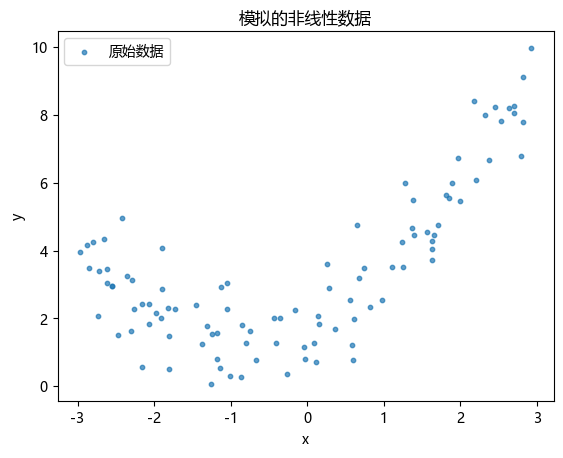

In [10]:
# 1. 准备环境与数据
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures        # 多项式特征
from sklearn.metrics import mean_squared_error, r2_score

# 设置随机种子 , 确保每次运行结果一致
np.random.seed(42)

# 创建模拟数据 : y 是 x 的二次函数加上一些随机噪声
X = 6 * np.random.rand(100, 1) - 3          # 生成 100 个在 [-3, 3) 之间的随机数
y = 0.5 * X ** 2 + X + 2 + np.random.randn(100 , 1)          # y = 0.5x^2 + x + 2 + 噪声


plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
# 可视化原始数据
plt.scatter(X, y, s=10, alpha=0.7, label='原始数据')
plt.xlabel('x')
plt.ylabel('y')
plt.title('模拟的非线性数据')
plt.legend()
plt.show()

In [ ]:
# 2. 特征转换与模型训练

# 创建多项式特征
# 参数 degree 决定了多项式的阶数 , 这里我们尝试选择 2 阶
poly_features = PolynomialFeatures(degree=2 , include_bias=False)               # include_bias=False 表示不添加偏置项 , 因为线性回归模型已经包含了偏置项
# 将原始特征 X 转换为包含 X 和 X^2 的多项式特征矩阵X_poly
X_poly = poly_features.fit_transform(X)

print(f"原始X的形状: {X.shape}")
print(f"转换后的X_poly的形状: {X_poly.shape}")
print(f"转换后的X_poly的前五行: {X_poly[:5]}")
# 输出显示 , X_poly 有两列 : 第一列是原始特征 X , 第二列是 X^2 , 这两个特征用于训练模型


# 在转换的特征上训练线性模型
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)          # 使用X_poly , 而不是原始特征X


# 查看学到的模型参数(权重和偏置项)
print(f"\n模型的权重: {lin_reg.coef_.ravel()}")             # ravel() 方法将权重向量转换为一维数组 , 方便查看
print(f"\n模型的偏置项: {lin_reg.intercept_}")

原始X的形状: (100, 1)
转换后的X_poly的形状: (100, 2)
转换后的X_poly的前五行: [[-0.75275929  0.56664654]
 [ 2.70428584  7.3131619 ]
 [ 1.39196365  1.93756281]
 [ 0.59195091  0.35040587]
 [-2.06388816  4.25963433]]

模型的权重: [0.93366893 0.56456263]

模型的偏置项: [1.78134581]
